# Smart Manufacturing Machines Efficiency Prediction

This notebook is the first end-to-end data science workflow for the Smart Manufacturing Machines Efficiency Prediction project. The goal is to understand the raw manufacturing dataset, define the target variable, build a simple baseline model, evaluate model quality, and document what should later be converted into production `src/*.py` modules.

This phase is intentionally notebook-first. It is not production code yet.

## 1. Project Objective

Business objective: estimate whether a manufacturing machine is operating with a specific efficiency status from machine telemetry, production, quality, and network indicators.

Modeling objective: train a supervised classification model to predict `Efficiency_Status`.

Recommended success metric: use macro F1-score as the primary metric because it treats each class more evenly when class distribution is imbalanced. Accuracy and weighted F1-score are also reported for interpretation.

In [2]:
from pathlib import Path
import shutil
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
ARTIFACT_RAW_DATA_DIR = PROJECT_ROOT / "artifacts" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = RAW_DATA_DIR / "manufacturing_6G_dataset.csv"
ARTIFACT_DATA_FILE = ARTIFACT_RAW_DATA_DIR / "manufacturing_6G_dataset.csv"

if not DATA_FILE.exists() and ARTIFACT_DATA_FILE.exists():
    shutil.copy2(ARTIFACT_DATA_FILE, DATA_FILE)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data file: {DATA_FILE}")

Project root: C:\Users\SIRIDACH JAROENSIRI\Desktop\MLOPS-SMART-MANUFACTURING-MACHINES-EFFICIENCY-PREDICTION
Raw data file: C:\Users\SIRIDACH JAROENSIRI\Desktop\MLOPS-SMART-MANUFACTURING-MACHINES-EFFICIENCY-PREDICTION\data\raw\manufacturing_6G_dataset.csv


## 2. Load Dataset

The raw dataset should be loaded from `data/raw/`. If the ingestion script downloaded the dataset into `artifacts/raw/`, the setup cell copies it into `data/raw/` for notebook experimentation.

In [3]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Raw dataset not found. Run `python src/data_ingestion.py` first, "
        "then confirm manufacturing_6G_dataset.csv exists in data/raw/ or artifacts/raw/."
    )

df = pd.read_csv(DATA_FILE)
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


## 3. Basic Data Understanding

This section checks dataset size, column names, data types, missing values, duplicates, and high-level summary statistics. These checks are required before modeling because they identify quality problems and possible leakage risks.

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
pd.DataFrame({"column": df.columns})

Rows: 100,000
Columns: 13


,column
0,Timestamp
1,Machine_ID
2,Operation_Mode
3,Temperature_C
4,Vibration_Hz
5,Power_Consumption_kW
6,Network_Latency_ms
7,Packet_Loss_%
8,Quality_Control_Defect_Rate_%
9,Production_Speed_units_per_hr


In [5]:
data_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})
data_profile

,dtype,missing_count,missing_percent,unique_values
Timestamp,object,0,0.0,100000
Machine_ID,int64,0,0.0,50
Operation_Mode,object,0,0.0,3
Temperature_C,float64,0,0.0,100000
Vibration_Hz,float64,0,0.0,100000
Power_Consumption_kW,float64,0,0.0,100000
Network_Latency_ms,float64,0,0.0,100000
Packet_Loss_%,float64,0,0.0,100000
Quality_Control_Defect_Rate_%,float64,0,0.0,100000
Production_Speed_units_per_hr,float64,0,0.0,100000


In [6]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")
df.describe(include="all").T

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,100000,100000,2024-03-10 10:23:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine_ID,100000.0,NaN,NaN,NaN,25.49933,14.389439,1.0,13.0,25.0,38.0,50.0
Operation_Mode,100000,3,Active,70054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature_C,100000.0,NaN,NaN,NaN,60.041458,17.323238,30.000138,45.031596,60.033597,74.967217,89.998979
Vibration_Hz,100000.0,NaN,NaN,NaN,2.549959,1.414127,0.100011,1.323214,2.549441,3.776459,4.999974
Power_Consumption_kW,100000.0,NaN,NaN,NaN,5.745929,2.451271,1.500183,3.627318,5.75546,7.860267,9.999889
Network_Latency_ms,100000.0,NaN,NaN,NaN,25.55562,14.120758,1.000025,13.355118,25.536079,37.796372,49.999917
Packet_Loss_%,100000.0,NaN,NaN,NaN,2.493418,1.443273,0.000026,1.245026,2.487667,3.741252,4.999975
Quality_Control_Defect_Rate_%,100000.0,NaN,NaN,NaN,5.008806,2.883666,0.000449,2.521591,5.003569,7.506127,9.9999
Production_Speed_units_per_hr,100000.0,NaN,NaN,NaN,275.916324,130.096892,50.000375,162.873618,276.648922,388.812761,499.996768


## 4. Target Variable Inspection

The target variable is `Efficiency_Status`. This makes the problem a multi-class classification task. The class distribution should be reviewed because strong imbalance can make accuracy misleading.

In [7]:
TARGET_COLUMN = "Efficiency_Status"

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Target column not found: {TARGET_COLUMN}")

target_distribution = df[TARGET_COLUMN].value_counts(dropna=False).to_frame("count")
target_distribution["percent"] = (target_distribution["count"] / len(df) * 100).round(2)
target_distribution

,count,percent
Efficiency_Status,,
Low,77825,77.82
Medium,19189,19.19
High,2986,2.99


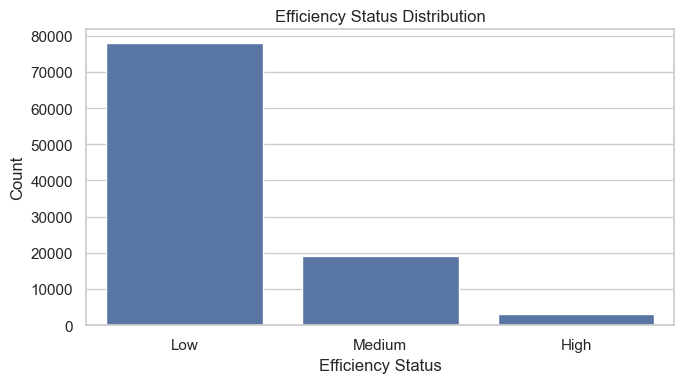

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COLUMN, order=df[TARGET_COLUMN].value_counts().index)
plt.title("Efficiency Status Distribution")
plt.xlabel("Efficiency Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 5. Business Meaning of Columns

- `Timestamp`: observation time for the machine telemetry record.
- `Machine_ID`: machine identifier.
- `Operation_Mode`: machine operating state such as active, idle, or maintenance.
- `Temperature_C`: operating temperature in Celsius.
- `Vibration_Hz`: vibration level.
- `Power_Consumption_kW`: power consumption.
- `Network_Latency_ms`: communication latency.
- `Packet_Loss_%`: network packet loss percentage.
- `Quality_Control_Defect_Rate_%`: defect rate from quality control.
- `Production_Speed_units_per_hr`: production throughput.
- `Predictive_Maintenance_Score`: machine maintenance risk or health indicator.
- `Error_Rate_%`: observed process or machine error rate.
- `Efficiency_Status`: target class to predict.

## 6. Basic EDA

This section reviews numeric distributions and relationships with the target. The goal is not to exhaust every possible chart, but to understand whether features look reasonable and whether obvious data quality issues exist.

In [9]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_columns, categorical_columns

(['Machine_ID',
  'Temperature_C',
  'Vibration_Hz',
  'Power_Consumption_kW',
  'Network_Latency_ms',
  'Packet_Loss_%',
  'Quality_Control_Defect_Rate_%',
  'Production_Speed_units_per_hr',
  'Predictive_Maintenance_Score',
  'Error_Rate_%'],
 ['Timestamp', 'Operation_Mode', 'Efficiency_Status'])

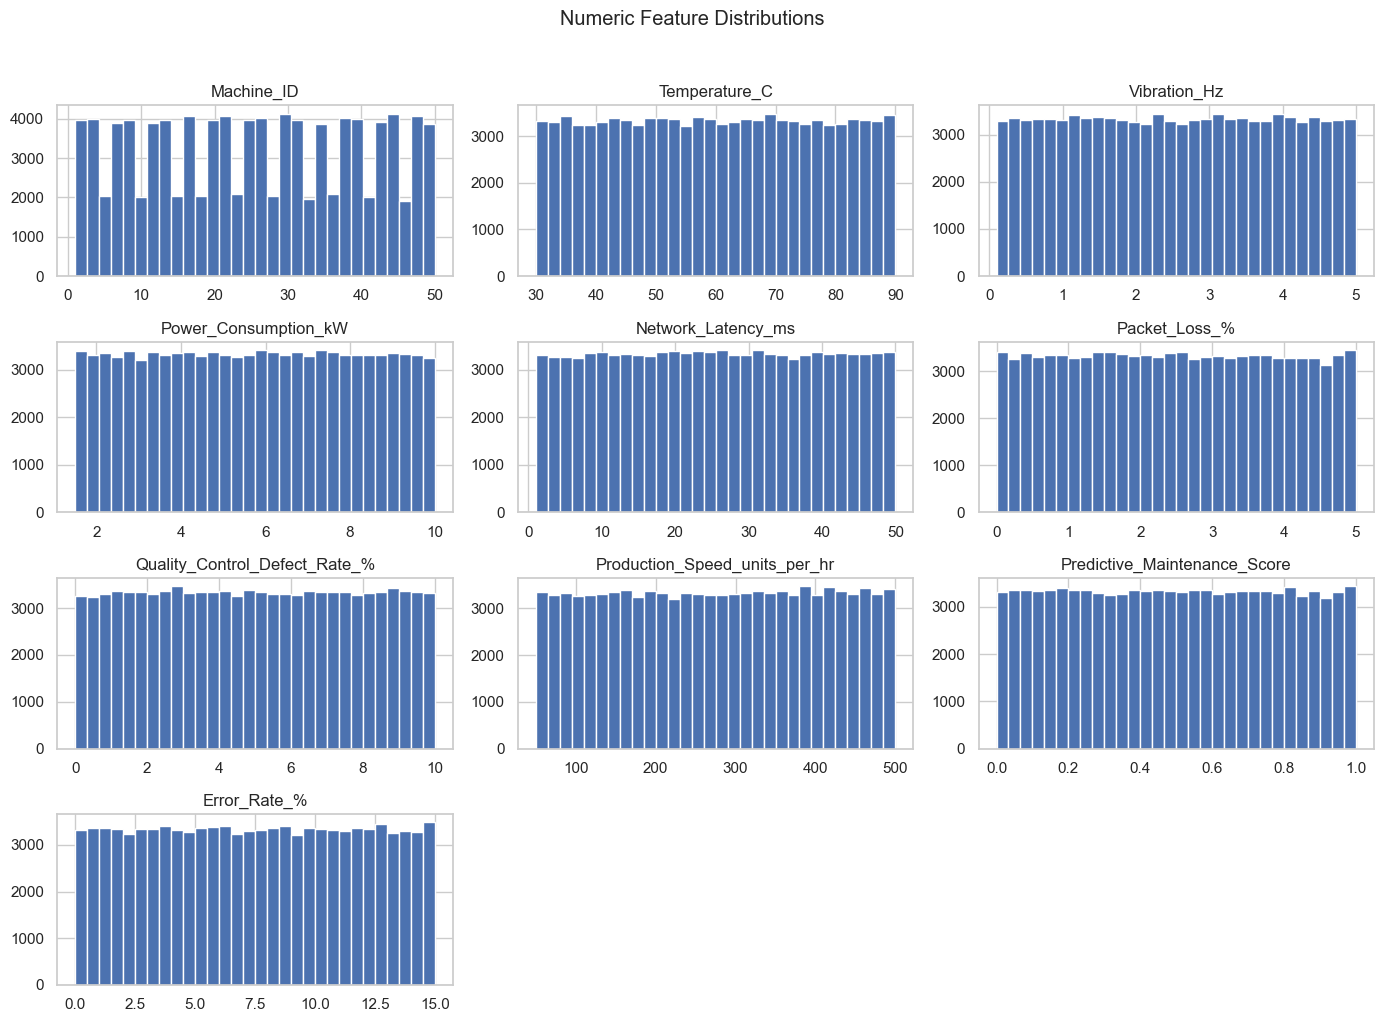

In [10]:
df[numeric_columns].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

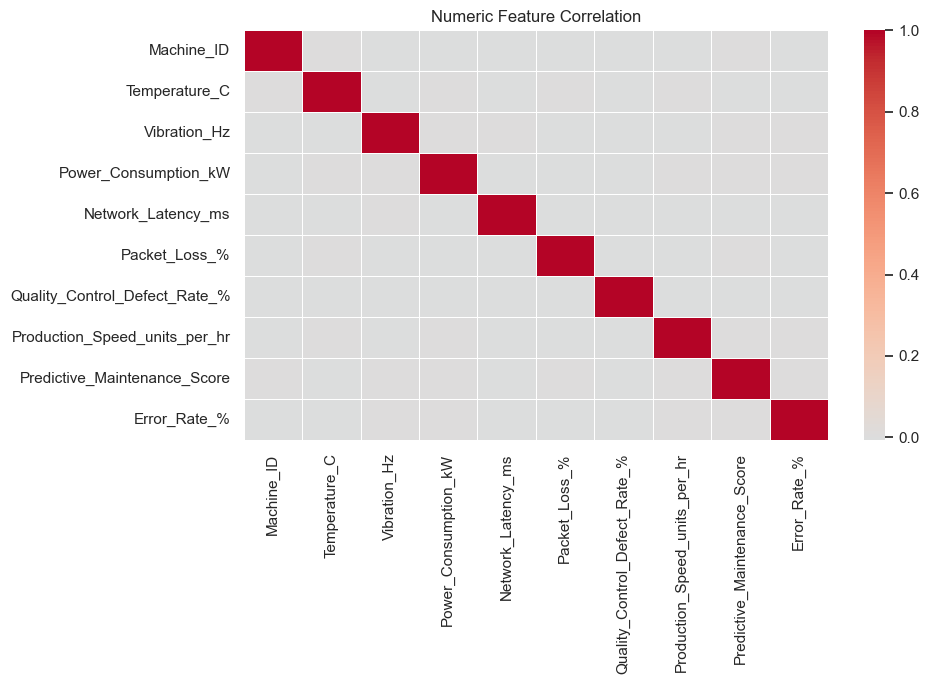

In [11]:
plt.figure(figsize=(10, 7))
corr = df[numeric_columns].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()

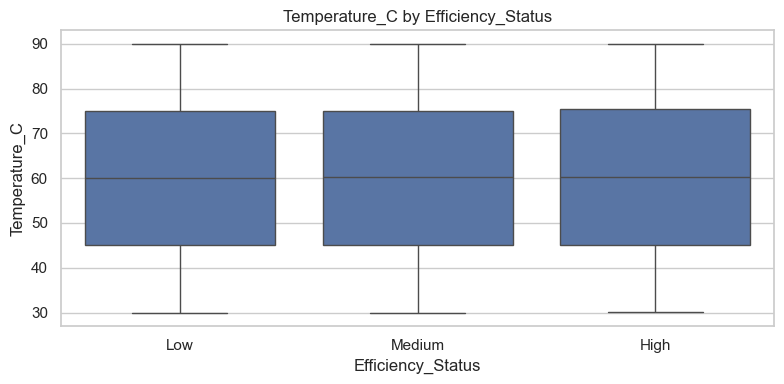

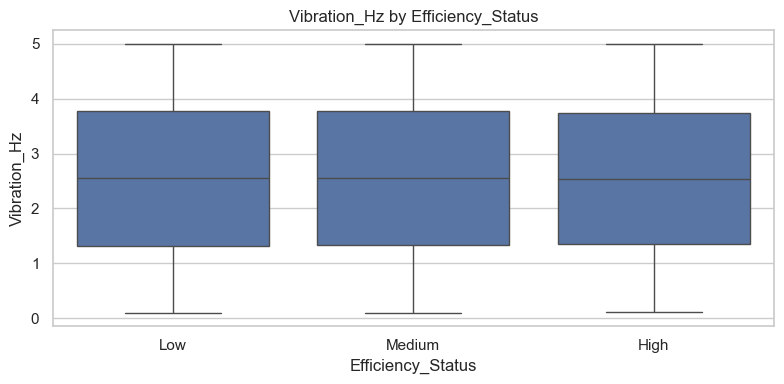

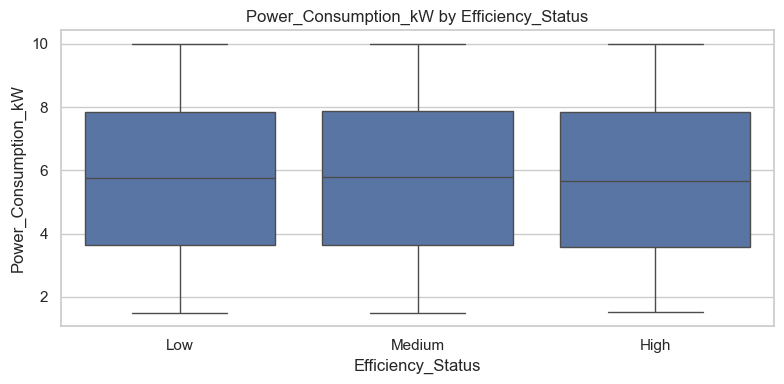

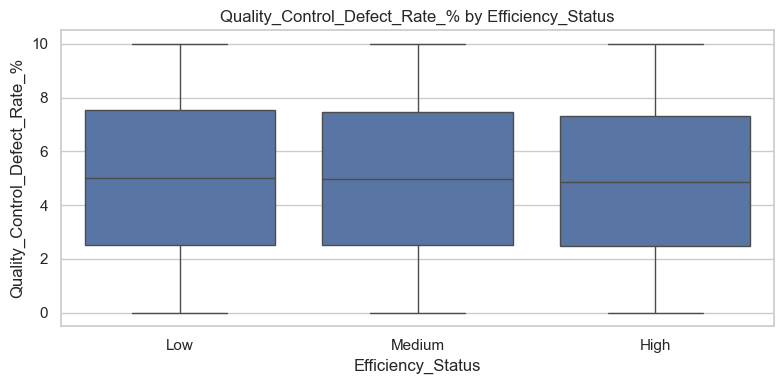

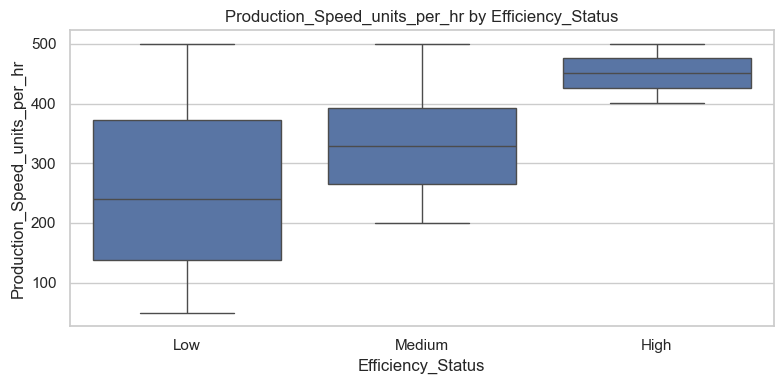

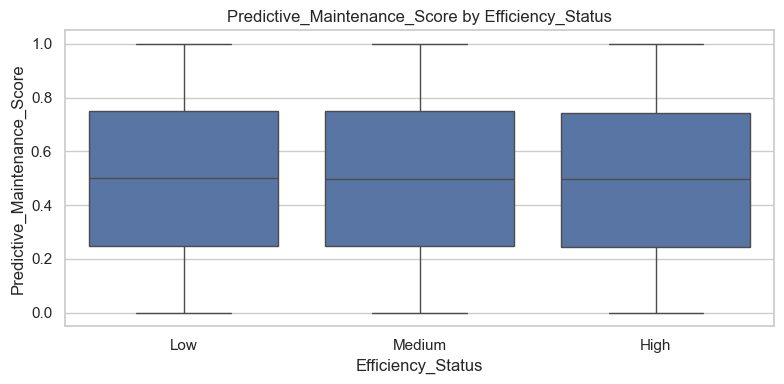

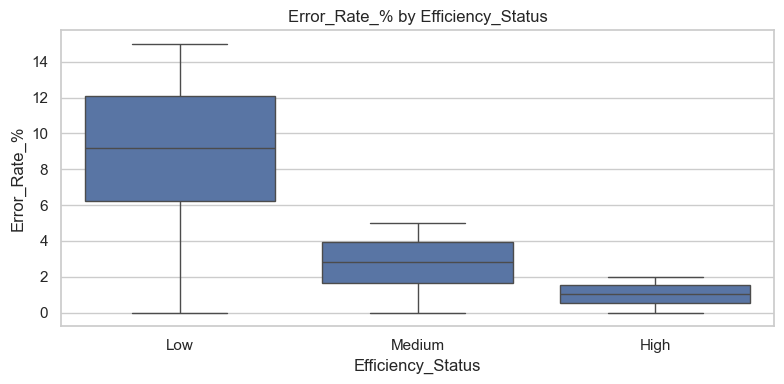

In [12]:
eda_features = [
    "Temperature_C",
    "Vibration_Hz",
    "Power_Consumption_kW",
    "Quality_Control_Defect_Rate_%",
    "Production_Speed_units_per_hr",
    "Predictive_Maintenance_Score",
    "Error_Rate_%"
]

for column in eda_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=TARGET_COLUMN, y=column)
    plt.title(f"{column} by {TARGET_COLUMN}")
    plt.tight_layout()
    plt.show()

## 7. Outlier Review

Outliers are reviewed with the IQR rule. In this notebook phase, outliers are documented but not aggressively removed because operational extremes can be meaningful in manufacturing data.

In [13]:
outlier_summary = []
for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_summary.append({
        "column": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(count),
        "outlier_percent": round(count / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,column,lower_bound,upper_bound,outlier_count,outlier_percent
0,Machine_ID,-24.500000,75.500000,0,0.0
1,Temperature_C,0.128165,119.870649,0,0.0
2,Vibration_Hz,-2.356653,7.456326,0,0.0
3,Power_Consumption_kW,-2.722104,14.209689,0,0.0
4,Network_Latency_ms,-23.306763,74.458254,0,0.0
5,Packet_Loss_%,-2.499312,7.485590,0,0.0
6,Quality_Control_Defect_Rate_%,-4.955213,14.982931,0,0.0
7,Production_Speed_units_per_hr,-176.035097,727.721476,0,0.0
8,Predictive_Maintenance_Score,-0.502800,1.499777,0,0.0
9,Error_Rate_%,-7.534414,22.557752,0,0.0


## 8. Feature Selection and Leakage Check

`Efficiency_Status` is the target and must not be used as an input feature. `Timestamp` is transformed into simple time features. The first baseline keeps the remaining telemetry, production, quality, maintenance, network, and operation mode fields.

In [14]:
model_df = df.copy()

model_df["Timestamp"] = pd.to_datetime(model_df["Timestamp"], errors="coerce")
model_df["hour"] = model_df["Timestamp"].dt.hour
model_df["day_of_week"] = model_df["Timestamp"].dt.dayofweek
model_df = model_df.drop(columns=["Timestamp"])

model_df = model_df.drop_duplicates()

X = model_df.drop(columns=[TARGET_COLUMN])
y = model_df[TARGET_COLUMN]

feature_columns = X.columns.tolist()
feature_columns

['Machine_ID',
 'Operation_Mode',
 'Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%',
 'hour',
 'day_of_week']

## 9. Train/Test Split

A stratified split is used so the train and test sets preserve the target class distribution. A fixed random seed improves reproducibility.

In [15]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
y_train.value_counts(normalize=True).round(3).to_frame("train_class_ratio")

Train shape: (80000, 13)
Test shape: (20000, 13)


,train_class_ratio
Efficiency_Status,
Low,0.778
Medium,0.192
High,0.030


## 10. Baseline Model Training

The baseline uses a simple preprocessing and logistic regression pipeline. Numeric features are imputed and scaled. Categorical features are imputed and one-hot encoded. Preprocessing is fit only on the training split to reduce leakage risk.

In [16]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 11. Model Evaluation

The baseline is evaluated on the held-out test set. Macro F1-score is emphasized because the target is imbalanced.

In [17]:
y_pred = baseline_model.predict(X_test)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "macro_f1": f1_score(y_test, y_pred, average="macro"),
    "weighted_f1": f1_score(y_test, y_pred, average="weighted")
}

pd.DataFrame([metrics]).round(4)

,accuracy,macro_f1,weighted_f1
0,0.8863,0.823,0.8927


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.67      0.96      0.79       597
         Low       0.98      0.89      0.93     15565
      Medium       0.66      0.85      0.74      3838

    accuracy                           0.89     20000
   macro avg       0.77      0.90      0.82     20000
weighted avg       0.91      0.89      0.89     20000



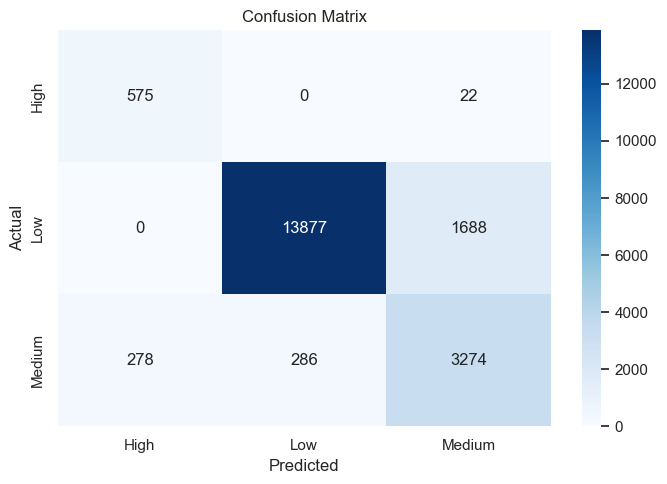

In [19]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 12. Error Analysis

Reviewing incorrect predictions helps identify whether errors are concentrated in a specific class or operating condition. This is important before choosing a stronger model.

In [20]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred
error_df["is_error"] = error_df["actual"] != error_df["predicted"]

error_rate_by_actual = error_df.groupby("actual")["is_error"].mean().sort_values(ascending=False).to_frame("error_rate")
error_rate_by_actual

,error_rate
actual,
Medium,0.146952
Low,0.108448
High,0.036851


In [21]:
error_examples = error_df[error_df["is_error"]].head(10)
error_examples

,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,hour,day_of_week,actual,predicted,is_error
48737,41,Active,32.502298,0.445714,8.858478,39.545757,4.724805,1.334047,76.518590,0.007504,0.749172,20,5,Low,Medium,True
76610,30,Active,68.118915,4.125652,9.985651,40.682390,3.051893,5.516680,85.301442,0.477155,1.533150,4,4,Low,Medium,True
56117,4,Idle,50.607623,4.670229,5.569904,8.162094,2.200719,7.815596,196.402306,0.278410,1.093090,23,3,Low,Medium,True
53307,10,Active,73.731857,1.383973,5.518291,35.072076,0.081104,0.825695,142.217896,0.154718,1.735475,0,2,Low,Medium,True
45582,7,Active,68.961642,2.969713,4.191079,25.066922,3.989201,0.221554,410.413659,0.835632,5.608412,15,3,Low,Medium,True
97326,17,Active,41.059918,4.968869,5.695169,19.684269,2.744533,2.437315,402.664460,0.746415,5.927709,14,4,Low,Medium,True
61012,50,Active,64.362253,3.963555,2.469853,15.199238,4.711481,7.774034,411.906423,0.267321,6.154977,8,0,Low,Medium,True
38719,45,Active,54.699021,0.202492,2.479468,47.627620,1.079306,7.949794,132.324694,0.097711,0.686423,21,5,Low,Medium,True
79297,14,Idle,83.274856,4.482493,6.759034,9.365005,1.542874,2.230882,77.453874,0.623448,0.513373,1,6,Low,Medium,True
40564,32,Active,65.548001,4.511583,4.656670,48.689282,3.427810,3.068329,85.221295,0.976175,0.933476,4,0,Low,Medium,True


## 13. Save Model Artifact

The model is saved as a notebook-phase artifact. In a later phase, the training and saving logic should be moved into production scripts.

In [22]:
model_path = MODEL_DIR / "baseline_efficiency_status_model.joblib"
joblib.dump(baseline_model, model_path)
print(f"Saved baseline model to: {model_path}")

Saved baseline model to: C:\Users\SIRIDACH JAROENSIRI\Desktop\MLOPS-SMART-MANUFACTURING-MACHINES-EFFICIENCY-PREDICTION\models\baseline_efficiency_status_model.joblib


## 14. Summary of Findings

Document after running the notebook:

- Dataset source: Kaggle dataset `ziya07/intelligent-manufacturing-dataset`, loaded locally from `data/raw/manufacturing_6G_dataset.csv`.
- Target variable: `Efficiency_Status`.
- Modeling type: multi-class classification.
- Candidate features: machine ID, operation mode, temperature, vibration, power consumption, network latency, packet loss, defect rate, production speed, maintenance score, error rate, and engineered time features.
- Initial data quality issues: review missing values, duplicates, outliers, and class imbalance from the notebook outputs.
- Primary metric: macro F1-score.
- Secondary metrics: accuracy, weighted F1-score, classification report, and confusion matrix.

## 15. Next Step: Convert Notebook Logic into `src/*.py`

In the next phase, convert this notebook into production modules:

- `src/data_processing.py`: load data, clean columns, handle missing values, remove duplicates, and save processed datasets.
- `src/feature_engineering.py`: create time-based features and any validated manufacturing features.
- `src/train_model.py`: train the model pipeline with fixed random seed and save the artifact.
- `src/evaluate_model.py`: calculate and persist evaluation metrics.
- `src/predict.py`: load the saved model and provide reusable prediction logic.

Keep preprocessing fit only on training data to avoid leakage.